# Fáza 3 - Strojové učenie: 20 bodov
Pri dátovej analýze nemusí byť naším cieľom získať len znalosti obsiahnuté v aktuálnych dátach, ale aj natrénovať model, ktorý bude schopný robiť rozumné predikcie pre nové pozorovania pomocou techniky strojového učenia. 

## 3.1 Jednoduchý klasifikátor na základe závislosti v dátach  (5b)
- (A-2b) Naimplementujte jednoduchý ID3 klasifikátor s hĺbkou min 2 (vrátane root/koreň). 
- (B-1b) Vyhodnoťte Váš ID3 klasifikátor pomocou metrík accuracy, precision a recall.
- (C-2b) Zístite či Váš ID3 klasifikátor má overfit. Ak áno, riešte aby nemal overfitting.

## 3.2 Trénovanie a vyhodnotenie klasifikátorov strojového učenia (5b)
- (A-1b) Na trénovanie využite jeden stromový algoritmus v scikit-learn.
- (B-1b) Porovnajte s jedným iným nestromovým algoritmom v scikit-learn.
- (C-1b) Porovnajte výsledky s ID3 z prvého kroku.
- (D-1b) Vizualizujte natrénované pravidlá minimálne pre jeden Vami vybraný algoritmus
- (E-1b) Vyhodnoťte natrénované modely pomocou metrík accuracy, precision a recall

## 3.3 Optimalizácia alias hyperparameter tuning (5b)
- (A-1b) Vyskúšajte rôzne nastavenie hyperparametrov (tuning) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu).
- (B-1b) Vyskúšajte kombinácie modelov (ensemble) pre zvolený algoritmus tak, aby ste optimalizovali výkonnosť (bez underfitingu). 
- (C-1b) Využite krížovú validáciu (cross validation) na trénovacej množine.
- (D-2b) Dokážte že Váš nastavený najlepší model je bez overfitingu.

## 3.4 Vyhodnotenie vplyvu zvolenej stratégie riešenia na klasifikáciu (5b) 
Vyhodnoťte Vami zvolené stratégie riešenia projektu z hľadiska classification accuracy, či sú učinné pre Váš dataset: 
- (A-1b) Stratégie riešenia v data preprocessingu s daným datasetom.
- (B-1b) Dátová transformácia (scaling, transformer, …)
- (C-1b) Výber atribútov, výber algoritmov, hyperparameter tuning, ensemble learning
- (D-1b) Ktorý model je Váš najlepší model pre nasadenie (deployment)? 
- (E-1b) Aký je data pipeline pre jeho vybudovanie na základe Vášho datasetu v produkcii?

Všetky hodnotenia podložte dôkazmi. Najlepší model má byť stabilný, bez overfitu a bez underfitu. Jeho data pipeline má byť dodaný s metadátami, ak tie metadáta sú potrebné a vyrobené v developmente.

In [14]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, RobustScaler
from sklearn.pipeline import Pipeline

In [15]:
mpl.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(palette="vanimo")

In [16]:
os.makedirs("pickles_ph3", exist_ok=True)

In [17]:
def histogramiada(df, bins=30):
    numeric_cols = df.select_dtypes(include=np.number).columns
    n_cols = len(numeric_cols)

    if n_cols == 0:
        print("[!] No numeric columns to plot.")
        return

    per_page = 9
    n_pages = int(np.ceil(n_cols / per_page))

    for page in range(n_pages):
        start = page * per_page
        end = start + per_page
        cols_subset = numeric_cols[start:end]

        fig, axes = plt.subplots(3, 3, figsize=(12, 10))
        axes = axes.flatten()

        for i, col in enumerate(cols_subset):
            sns.histplot(df[col], bins=bins, kde=True, ax=axes[i],
                         color=sns.color_palette("tab10")[i % 10])
            axes[i].set_title(col, fontsize=11)
            axes[i].set_xlabel("")
            axes[i].set_ylabel("")

        # hide unused subplots if fewer than 9
        for j in range(len(cols_subset), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(f"Numeric Columns {start + 1}–{min(end, n_cols)}", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

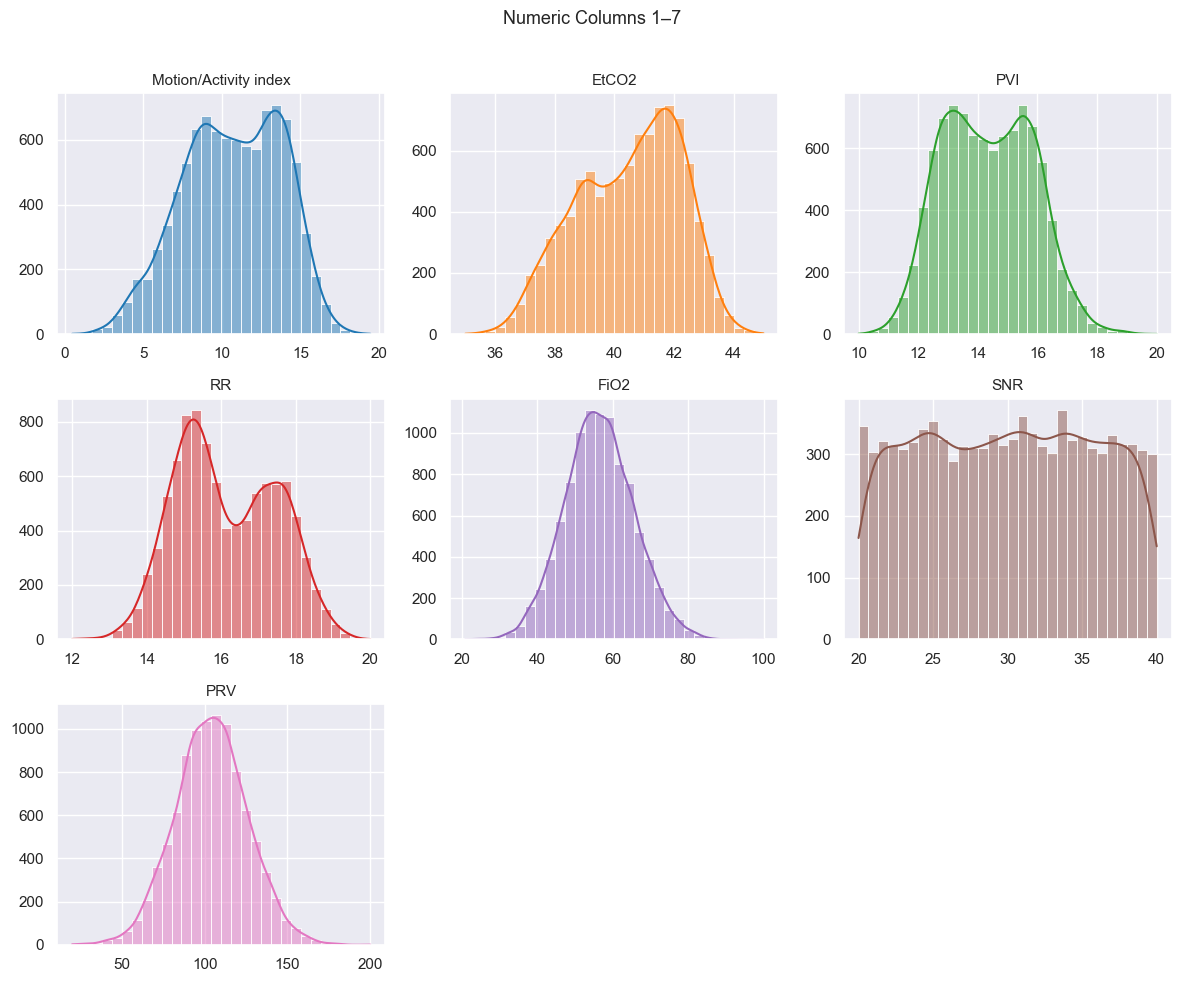

['pickles_ph3/preprocessing_pipeline.pkl']

In [18]:
df_observation = pd.read_csv('datasets/observation.csv',sep='\t')

df_observation.rename(
    columns={
        "SpO₂": "SpO2",
        "EtCO₂": "EtCO2",
        "FiO₂": "FiO2",
        "O₂ extraction ratio": "O2 extraction ratio"
    },
    inplace=True
)

# vieme z fazy 2
selected_features = ["Motion/Activity index", "EtCO2", "PVI", "RR", "FiO2", "SNR", "PRV", "oximetry"]

df = df_observation[selected_features]

X = df.drop(columns=["oximetry"])
y = df["oximetry"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

histogramiada(X_train)

pipeline = Pipeline(
    steps=[
        ('quantile_transformer', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('robust_scaler', RobustScaler())
    ]
)

pipeline.fit(X_train)

X_train_processed = pipeline.transform(X_train)
X_test_processed  = pipeline.transform(X_test)

X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns, index=X_train.index)
X_test_processed  = pd.DataFrame(X_test_processed, columns=X_test.columns, index=X_test.index)

joblib.dump(pipeline, "pickles_ph3/preprocessing_pipeline.pkl")

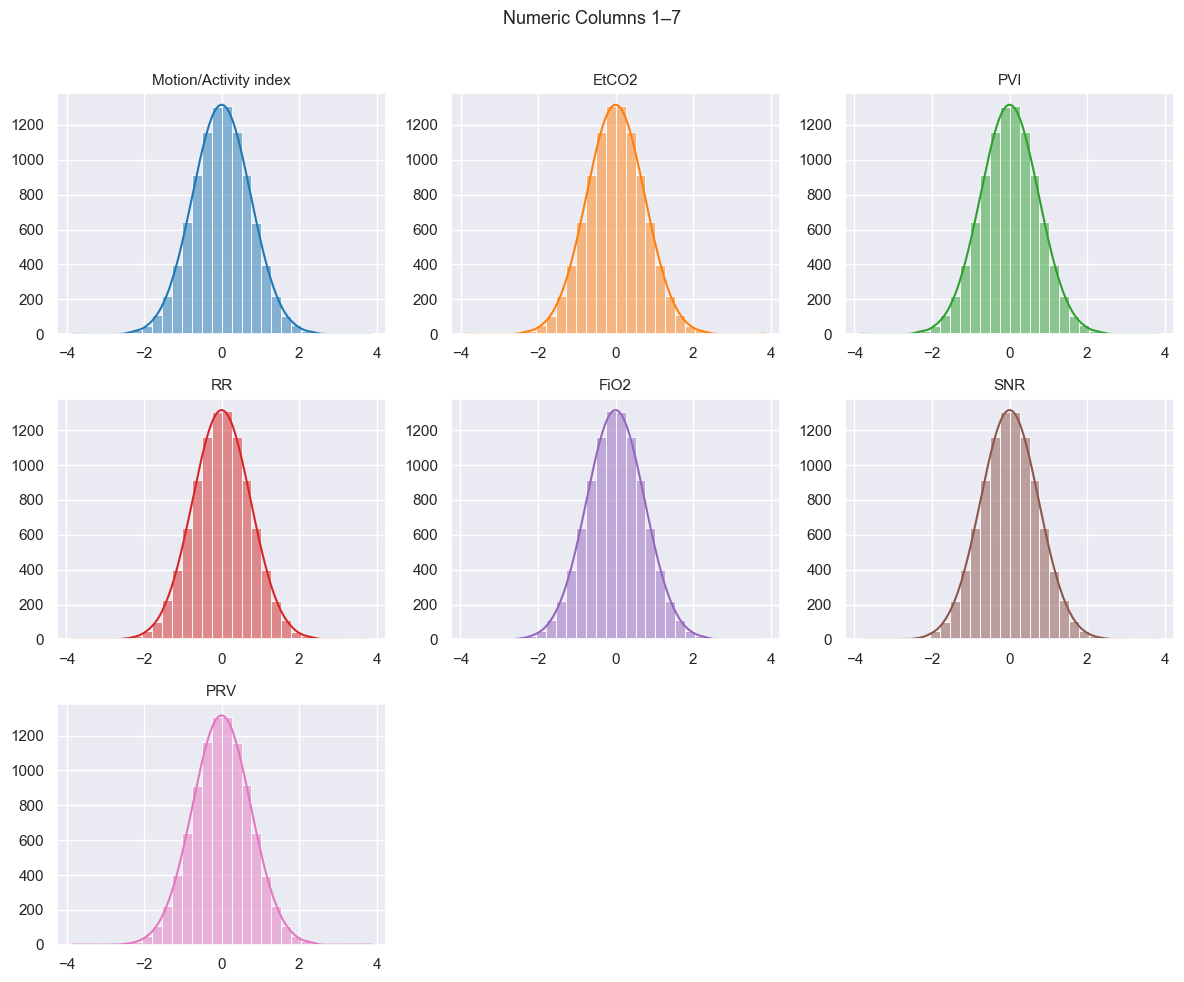

In [19]:
histogramiada(X_train_processed)